In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, StandardScaler, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import lightgbm as lgb

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')

/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


In [2]:
df_train


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [4]:
numerical_col = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
                'Environmental_Concern_Level', ]
categorical_col = ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV']
target_col = ['Will_Buy_EV']
map = {
    'Yes': 1,
    'No': 0
}
df_target = df_train['Will_Buy_EV'].map({'Yes': 1, 'No': 0})



<Axes: >

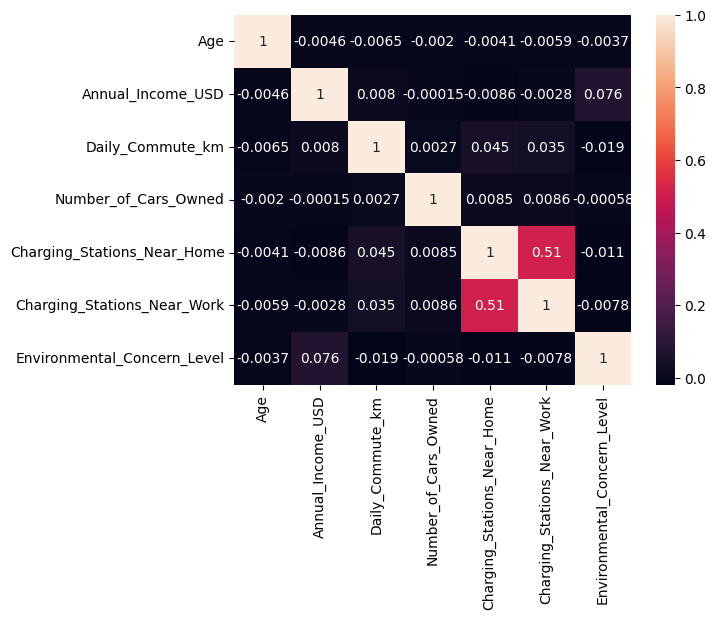

In [5]:
df_corr_matrix = df_train[numerical_col].corr()
sns.heatmap(df_corr_matrix, annot=True)

<Axes: >

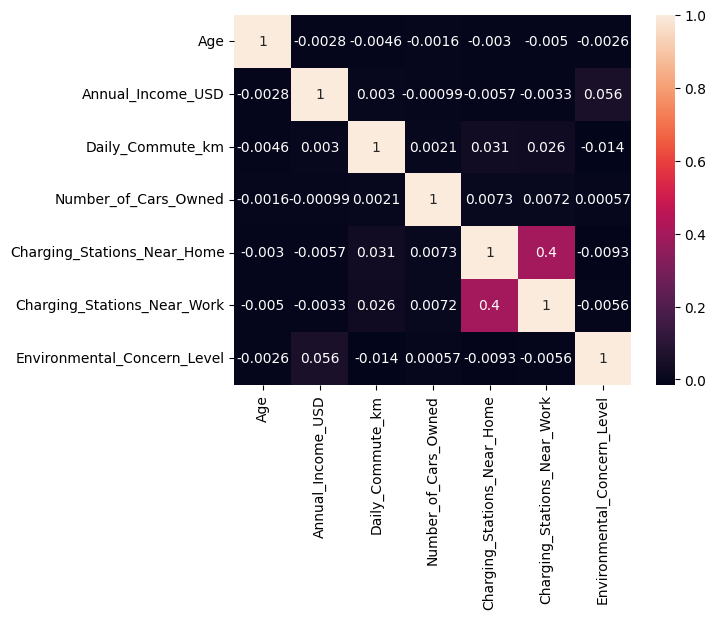

In [6]:
spearman_cof = df_train[numerical_col].corr(method='kendall')
sns.heatmap(spearman_cof, annot=True)
#As we can see the correlation map have only 2 parametrms with relationship

In [7]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
mi_scores = mutual_info_regression(df_train[numerical_col], df_target)
print(mi_scores)

[1.51285741e-03 5.25147394e-02 3.98977754e-03 1.03494610e-04
 1.03191308e-03 0.00000000e+00 1.25798859e-01]


[LightGBM] [Info] Number of positive: 116779, number of negative: 551886
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 668665, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174645 -> initscore=-1.553058
[LightGBM] [Info] Start training from score -1.553058


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


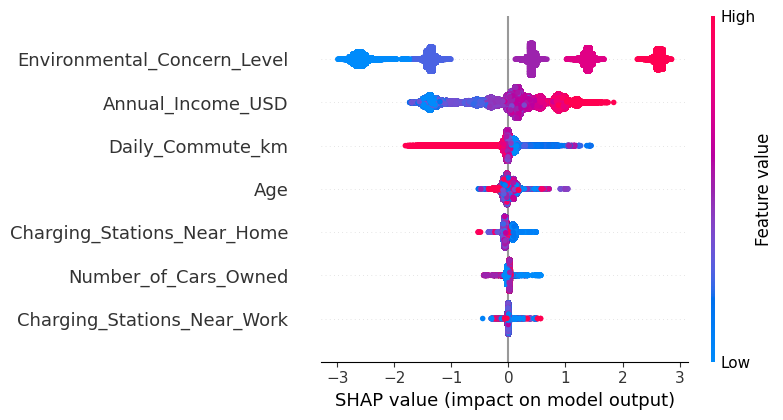

In [8]:
#Final steps of EDA, now we have the relationship between data 
import lightgbm as lgb
import shap

X = df_train[numerical_col]
y = df_target
model = lgb.LGBMClassifier(random_state=42)
model.fit(X, y)
explainer = shap.TreeExplainer(model)
shap_values= explainer.shap_values(X)
if isinstance(shap_values, list):
    shap.summary_plot(shap_value[1], X)
else:
    shap.summary_plot(shap_values, X)

/tmp/ipykernel_16/3324255682.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16/3324255682.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16/3324255682.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16/3324255682.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_16/3324255682.py:12: FutureWarning: 

Passing `pa

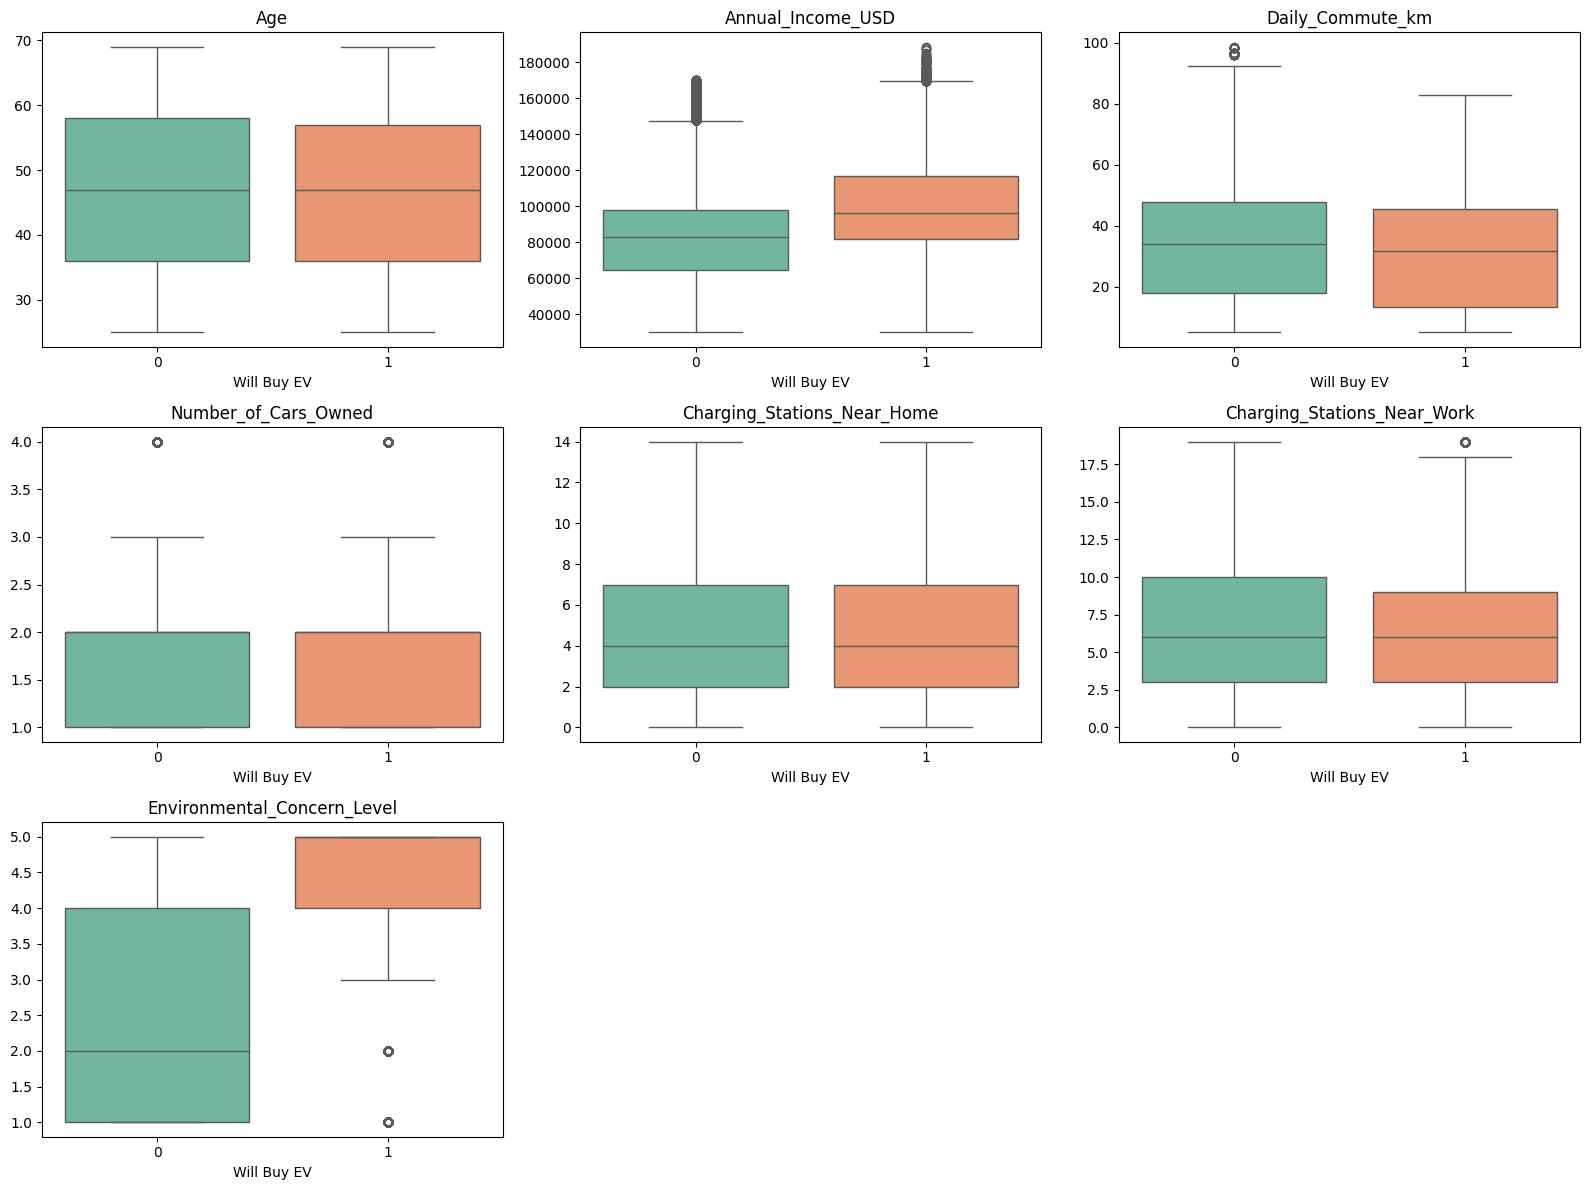

In [9]:


target_col = 'Will_Buy_EV'
y = df_target[target_col] if hasattr(df_target, 'columns') else df_target

n_features = len(numerical_col)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(numerical_col):
    sns.boxplot(
        x=y,
        y=df_train[col],
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Will Buy EV')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
from scipy.stats import chi2_contingency
target_name = 'Will_Buy_EV'
#Using chi2 contingency to access the connection beetween categorical data and target column
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/ n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1) * (r- 1)) / (n - 1))
    rcorr = r - ((r-1) **2) / (n-1)
    kcorr = k - ((k-1 ) **2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
for col in categorical_col:
    score = cramers_v(df_train[col], df_train[target_name])
    print(f'Cramers V for {col}: {score:.4f}')
    #Subsidy_Available is strong signal with target
    #Range_Anxiety_Level is the column with second medium connection with target

Cramers V for Gender: 0.0068
Cramers V for City_Type: 0.0333
Cramers V for Current_Car_Type: 0.0160
Cramers V for Home_Charging_Possible: 0.0836
Cramers V for Subsidy_Available: 0.3424
Cramers V for Range_Anxiety_Level: 0.1159
Cramers V for Will_Buy_EV: 1.0000


In [11]:
def generate_ev_features(df):
    df = df.copy()
    
    df['Total_Charging_Stations'] = df['Charging_Stations_Near_Home'] + df['Charging_Stations_Near_Work']
    df['Commute_per_Station'] = df['Daily_Commute_km'] / (df['Total_Charging_Stations'] + 1)
    home_charge = (df['Home_Charging_Possible'] == 'Yes').astype(int)
    df['Commute_with_Home_Charge'] = df['Daily_Commute_km'] * (1 - 0.5 * home_charge)
    df['Commute_No_Home_Charge'] = df['Daily_Commute_km'] * (1 - home_charge)
    df['High_Commute_Risk'] = (df['Daily_Commute_km'] > 45).astype(int)
    df['Log_Annual_Income'] = np.log1p(df['Annual_Income_USD'])
    df['Income_per_Car'] = df['Annual_Income_USD'] / (df['Number_of_Cars_Owned'] + 1)
    subsidy_flag = (df['Subsidy_Available'] == 'Yes').astype(int)
    df['Car_Type_Freq'] = df['Current_Car_Type'].map(df_train['Current_Car_Type'].value_counts(normalize=True))
    df['Income_Subsidy_Interaction'] = df['Log_Annual_Income'] * subsidy_flag
    df['Is_Max_Eco_Concern'] = (df['Environmental_Concern_Level'] == 5).astype(int)
    
    df['Eco_Wealth_Score'] = df['Environmental_Concern_Level'] * df['Log_Annual_Income']
    
    anxiety_map = {'Low': 1, 'Medium': 2, 'High': 3}
    anxiety_score = df['Range_Anxiety_Level'].map(anxiety_map).fillna(2)
    df['Commute_Stress_Index'] = df['Daily_Commute_km'] * anxiety_score
    
    df['Subsidy_x_Anxiety'] = df['Subsidy_Available'].astype(str) + '_' + df['Range_Anxiety_Level'].astype(str)
    
    return df

In [12]:
df_train.isnull().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [13]:
feature_generator = FunctionTransformer(generate_ev_features)
num_cols = list(numerical_col) + [
    'Total_Charging_Stations', 'Commute_per_Station', 'Commute_with_Home_Charge',
    'Commute_No_Home_Charge', 'Log_Annual_Income', 'Income_per_Car',
    'Income_Subsidy_Interaction', 'Eco_Wealth_Score', 'Commute_Stress_Index',
    'High_Commute_Risk', 'Is_Max_Eco_Concern', 'Car_Type_Freq'
]
cat_cols = [col for col in categorical_col if col != 'Will_Buy_EV'] + ['Subsidy_x_Anxiety']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', TargetEncoder(cv=5, smooth='auto', random_state=42), cat_cols)
])
full_pipeline = Pipeline(steps=[
    ('fe', feature_generator),
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        random_state=42,
        n_estimators=1000,
        learning_rate=0.02,
        num_leaves=31,
        reg_lambda=3.0,
        reg_alpha=0.5,
        colsample_bytree=0.8,
        subsample=0.8,
        subsample_freq=1,
        min_child_samples=50,
        verbosity=-1
    ))
])

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
y = df_target['Will_Buy_EV'] if hasattr(df_target, 'columns') else df_target
import warnings
warnings.filterwarnings('ignore')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(df_train))
test_preds = np.zeros(len(df_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, y)):
    X_tr, y_tr = df_train.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = df_train.iloc[val_idx], y.iloc[val_idx]
    
    full_pipeline.fit(X_tr, y_tr)
    
    val_probs = full_pipeline.predict_proba(X_va)[:, 1]
    oof_preds[val_idx] = val_probs
    test_preds += full_pipeline.predict_proba(df_test)[:, 1] / skf.n_splits
    
    print(f"Fold {fold + 1} ROC-AUC: {roc_auc_score(y_va, val_probs):.5f}")

print(f"OOF ROC-AUC: {roc_auc_score(y, oof_preds):.5f}")

submission = pd.DataFrame({
    'id': df_test['id'],
    'Will_Buy_EV': test_preds
})
submission.to_csv('submission.csv', index=False)


Fold 1 ROC-AUC: 0.94084
Fold 2 ROC-AUC: 0.94173
Fold 3 ROC-AUC: 0.94303
Fold 4 ROC-AUC: 0.94261
Fold 5 ROC-AUC: 0.94192
OOF ROC-AUC: 0.94202


1. ROC-AUC 0.94177(Sumbission 0.94157)18:38, 28.09.26 no changes
2. ROC-AUC 0.94178(Submission 0.94159) 18:56, add some new features
3. ROC-AUC 0.91486(Submission 0.94171) 19:02, some hyperparametrs for lgbmClassifier
4. 
